# Descriptor vs Measured Trait Validation

**Goal.** Verify that the parameter values written in the XML descriptor (e.g. `leafLength`, `leafAzimuthDeg`) are faithfully recovered when the procedural model reconstructs the leaf geometry and traits are extracted from the resulting splines.

**Method.** For each of the 500 plant descriptors in `PlantsC++/`:

1. **Parse the XML** to read the raw input parameters per leaf (`leafLength`, `leafAzimuthDeg`, `leafAngle`, `distance`, `leafWidth`, `droopiness`, etc.).
2. **Run the C++ engine** (via `phenosuite.wrapper.Maize`) to reconstruct the 3D geometry and extract spline-based traits.
3. **Run the Python forward model** (via `phenosuite.traits.compute_traits_from_descriptor`) to extract the same traits from the pure-Python reimplementation.
4. **Compare** declared descriptor values against the measured traits from both pipelines.

**Key comparisons:**

| XML parameter | Measured trait | Expected relationship |
|---|---|---|
| `leafLength` | Arc length of center spline | Should match closely; small differences from spline curvature |
| `leafAzimuthDeg` | Azimuth from base tangent | Should match exactly; direct placement parameter |
| `leafAngle` | Inclination from base tangent | *Not* expected to match — `leafAngle` is the target direction, but droopiness and curvature modify the actual base tangent |
| `distance` | Inter-leaf vertical spacing | Cumulative sum should track connection-point heights |

**Why this matters.** If the declared leaf length in the XML doesn't match the measured arc length from the reconstructed geometry, the descriptor format is inconsistent with the model — parameters would mean something different from what they claim. This check validates the full round-trip: XML → forward model → geometry → trait extraction.

In [1]:
import sys
from pathlib import Path
import xml.etree.ElementTree as ET

REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == '01_phyllotaxis' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from phenosuite.wrapper import Maize
from phenosuite.traits import compute_traits_from_descriptor

FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path('outputs'); OUT_DIR.mkdir(exist_ok=True)

PLANTS_DIR = REPO_ROOT / 'PlantsC++'
xml_files = sorted(PLANTS_DIR.glob('plant_*.xml'))
print(f'Found {len(xml_files)} plant XMLs in {PLANTS_DIR.name}/')

Found 500 plant XMLs in PlantsC++/


## 1. Parse raw descriptor parameters from XML

Extract the declared values directly from the XML attributes — these are the "ground truth" inputs to the procedural model.

In [2]:
def parse_xml_descriptor(xml_path):
    """Extract all raw leaf parameters from an XML descriptor.
    
    Returns (plant_meta, leaves) where plant_meta is a dict of plant-level
    attributes and leaves is a list of per-leaf dicts.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    plant_meta = {
        'species': root.get('species', ''),
        'phenotypeId': root.get('phenotypeId', ''),
    }
    
    # Handle both modern and legacy XML formats
    tiller_parent = root.find('species')
    if tiller_parent is None:
        tiller_parent = root
    
    leaves = []
    for tiller in tiller_parent.findall('Tiller'):
        tiller_radius = float(tiller.get('radius', 0.02))
        tiller_stem_shrink = float(tiller.get('stemShrink', 0.001))
        
        leaves_elem = tiller.find('leaves')
        if leaves_elem is None:
            continue
        for lf in leaves_elem.findall('leaf'):
            leaves.append({
                'id': int(lf.get('id', 0)),
                'distance': float(lf.get('distance', 0)),
                'leafLength': float(lf.get('leafLength', 0.7)),
                'leafWidth': float(lf.get('leafWidth', 0.08)),
                'leafAzimuthDeg': float(lf.get('leafAzimuthDeg', 0)),
                'leafAngle': float(lf.get('leafAngle', 45)),
                'droopiness': float(lf.get('droopiness', 0.5)),
                'stemInclinationDeg': float(lf.get('stemInclinationDeg', 0)),
                'splinePoints': int(lf.get('splinePoints', 4)),
                'widthTaper': float(lf.get('widthTaper', 1.0)),
                'leafTwist': float(lf.get('leafTwist', 0.0)),
                'leafCurl': float(lf.get('leafCurl', 0.0)),
                'tiller_radius': tiller_radius,
                'tiller_stem_shrink': tiller_stem_shrink,
            })
    return plant_meta, leaves


# Quick test
meta, test_leaves = parse_xml_descriptor(xml_files[0])
print(f'Plant 0 ({meta["phenotypeId"]}): {len(test_leaves)} leaves')
for i in [0, 6, 13]:
    lf = test_leaves[i]
    print(f'  Leaf {lf["id"]}: length={lf["leafLength"]:.4f} m, '
          f'azimuth={lf["leafAzimuthDeg"]:.2f} deg, '
          f'angle={lf["leafAngle"]:.2f} deg, '
          f'droop={lf["droopiness"]:.2f}')

Plant 0 (BTx99): 14 leaves
  Leaf 0: length=0.4380 m, azimuth=4.84 deg, angle=2.71 deg, droop=-95.15
  Leaf 6: length=0.6192 m, azimuth=357.73 deg, angle=45.38 deg, droop=-101.67
  Leaf 13: length=0.2167 m, azimuth=169.29 deg, angle=104.81 deg, droop=-79.78


## 2. Extract measured traits via C++ and Python pipelines

For every plant, run both engines and collect per-leaf measured traits alongside the XML declared values.

In [3]:
records = []
failures = []

for xi, xml_path in enumerate(xml_files):
    if (xi + 1) % 100 == 0:
        print(f'  {xi+1}/{len(xml_files)}...')
    
    plant_name = xml_path.stem
    
    try:
        _, xml_leaves = parse_xml_descriptor(xml_path)
        
        # --- C++ traits ---
        with Maize() as gen:
            gen.set_global_settings(200.0, 200.0, 0.15, 0, 0.15)
            if not gen.load_xml(str(xml_path), rebuild=True):
                failures.append((plant_name, 'CppLoadError', 'load_xml returned False'))
                continue
            n_cpp = gen.leaf_spline_trait_count()
            cpp_traits = [gen.get_leaf_spline_traits(i) for i in range(n_cpp)]
        
        # --- Python traits ---
        py_traits = compute_traits_from_descriptor(xml_path)
        
        n = min(len(xml_leaves), len(cpp_traits), len(py_traits))
        
        for i in range(n):
            xp = xml_leaves[i]
            ct = cpp_traits[i]
            pt = py_traits[i]
            
            records.append({
                'plant': plant_name,
                'leaf_id': xp['id'],
                'n_leaves': n,
                # --- XML declared values ---
                'xml_length': xp['leafLength'],
                'xml_azimuth': xp['leafAzimuthDeg'],
                'xml_angle': xp['leafAngle'],
                'xml_droopiness': xp['droopiness'],
                'xml_distance': xp['distance'],
                'xml_width': xp['leafWidth'],
                'xml_splinePoints': xp['splinePoints'],
                'xml_curl': xp['leafCurl'],
                # --- C++ measured traits ---
                'cpp_length': ct['leaf_length'],
                'cpp_azimuth': ct['leaf_angle']['azimuth_deg'],
                'cpp_inclination': ct['leaf_angle']['inclination_deg'],
                'cpp_conn_x': ct['connection_point']['x'],
                'cpp_conn_y': ct['connection_point']['y'],
                'cpp_conn_z': ct['connection_point']['z'],
                # --- Python measured traits ---
                'py_length': pt['leaf_length'],
                'py_azimuth': pt['leaf_angle']['azimuth_deg'],
                'py_inclination': pt['leaf_angle']['inclination_deg'],
                'py_conn_x': pt['connection_point']['x'],
                'py_conn_y': pt['connection_point']['y'],
                'py_conn_z': pt['connection_point']['z'],
            })

    except Exception as e:
        failures.append((plant_name, type(e).__name__, str(e)[:120]))

df = pd.DataFrame(records)

# Derived columns
df['cpp_length_err_mm'] = (df['cpp_length'] - df['xml_length']) * 1000
df['py_length_err_mm']  = (df['py_length']  - df['xml_length']) * 1000

# Azimuth difference with wrap-around handling
def azimuth_diff(measured, declared):
    d = measured - declared
    return ((d + 180) % 360) - 180

df['cpp_azimuth_err'] = azimuth_diff(df['cpp_azimuth'], df['xml_azimuth'])
df['py_azimuth_err']  = azimuth_diff(df['py_azimuth'],  df['xml_azimuth'])

print(f'Collected {len(df)} leaves from {df["plant"].nunique()} plants.')
print(f'Failures: {len(failures)}')
if failures:
    for name, etype, msg in failures[:5]:
        print(f'  {name}: {etype}: {msg}')

  100/500...
  200/500...
  300/500...
  400/500...
  500/500...
Collected 6213 leaves from 500 plants.
Failures: 0


## 3. Leaf length: XML declared vs measured

This is the primary validation. The `leafLength` parameter in the XML sets the total arc length that the forward model distributes across `splinePoints - 1` equal segments. The measured arc length (from B-spline sampling with 128 steps) should closely reproduce this value.

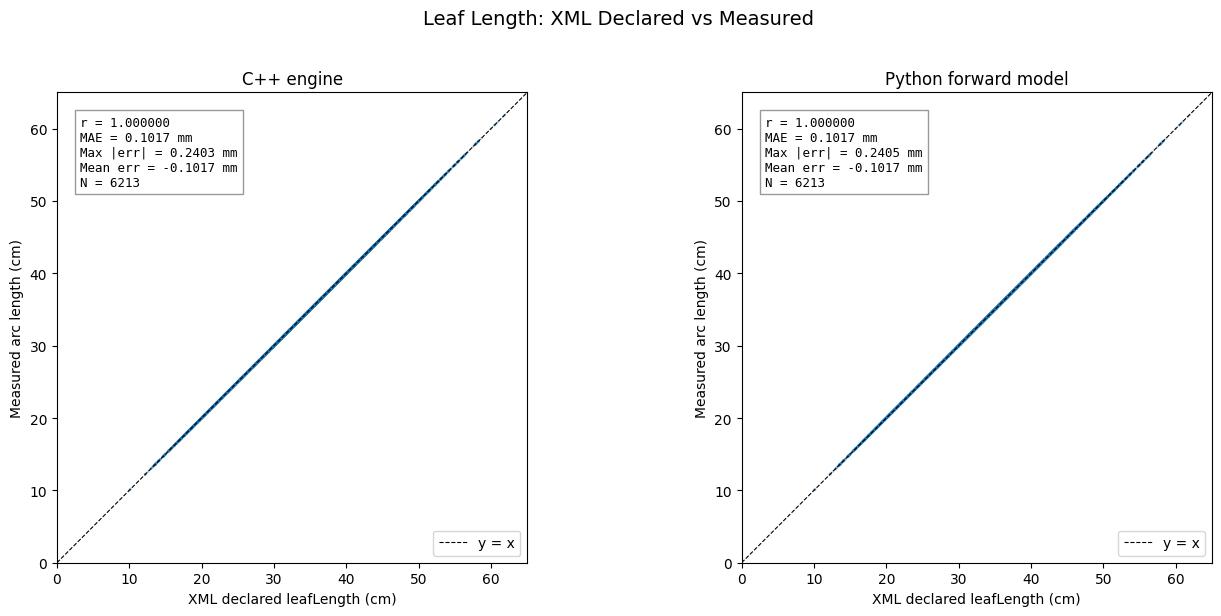

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prefix, label in zip(axes, ['cpp', 'py'], ['C++ engine', 'Python forward model']):
    measured = df[f'{prefix}_length'] * 100   # m → cm
    declared = df['xml_length'] * 100

    ax.scatter(declared, measured, s=4, alpha=0.3, edgecolors='none')
    lims = [0, max(declared.max(), measured.max()) * 1.05]
    ax.plot(lims, lims, 'k--', lw=0.8, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('XML declared leafLength (cm)')
    ax.set_ylabel('Measured arc length (cm)')
    ax.set_title(f'{label}')
    ax.set_aspect('equal')

    r, p = pearsonr(declared, measured)
    err_mm = (measured - declared) * 10  # cm → mm
    stats_text = (
        f'r = {r:.6f}\n'
        f'MAE = {np.abs(err_mm).mean():.4f} mm\n'
        f'Max |err| = {np.abs(err_mm).max():.4f} mm\n'
        f'Mean err = {err_mm.mean():.4f} mm\n'
        f'N = {len(declared)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', fontsize=9, family='monospace',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.legend(loc='lower right')

fig.suptitle('Leaf Length: XML Declared vs Measured', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'length_declared_vs_measured.png', dpi=150, bbox_inches='tight')
plt.show()

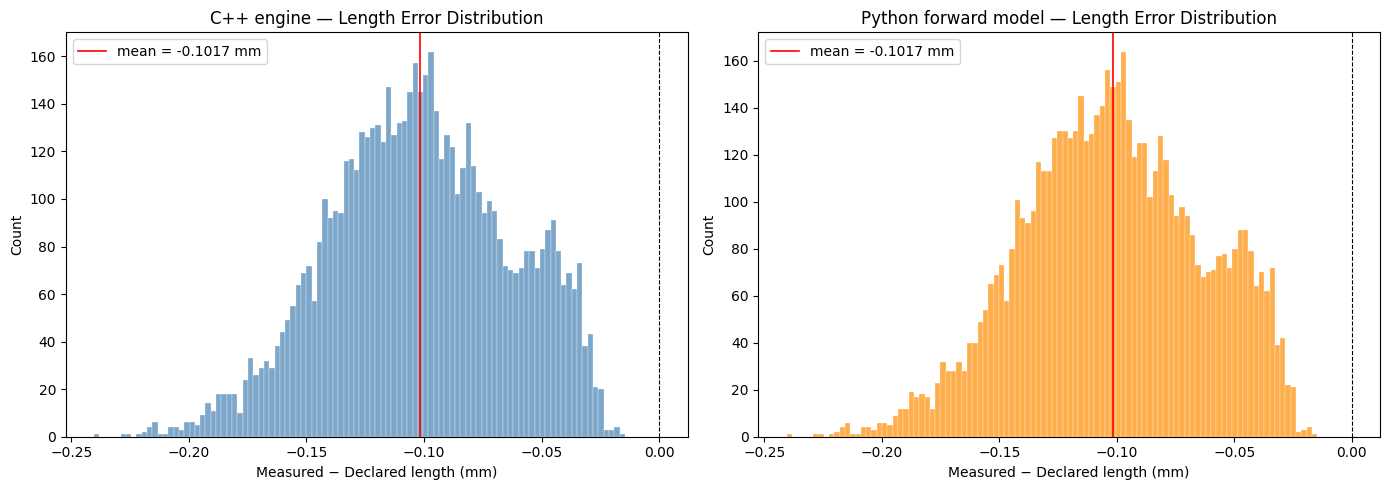


C++ length error (mm):
  P 50:   0.1022 mm
  P 90:   0.1510 mm
  P 95:   0.1656 mm
  P 99:   0.1916 mm
  P100:   0.2403 mm

Python length error (mm):
  P 50:   0.1022 mm
  P 90:   0.1511 mm
  P 95:   0.1656 mm
  P 99:   0.1917 mm
  P100:   0.2405 mm


In [5]:
# Error distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prefix, label, color in zip(axes, ['cpp', 'py'],
                                     ['C++ engine', 'Python forward model'],
                                     ['steelblue', 'darkorange']):
    err = df[f'{prefix}_length_err_mm']
    ax.hist(err, bins=100, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(err.mean(), color='red', lw=1.2, ls='-', label=f'mean = {err.mean():.4f} mm')
    ax.set_xlabel('Measured − Declared length (mm)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Length Error Distribution')
    ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'length_error_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Percentile summary
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err = df[f'{prefix}_length_err_mm']
    print(f'\n{label} length error (mm):')
    for pct in [50, 90, 95, 99, 100]:
        print(f'  P{pct:3d}: {np.percentile(np.abs(err), pct):8.4f} mm')

## 4. Azimuth: XML declared vs measured

The `leafAzimuthDeg` parameter is a direct placement angle — it sets the compass direction of the leaf around the stem. Both pipelines should recover this value exactly from the base tangent direction.

**Caveat:** When `leafAngle > ~85°`, the leaf is nearly vertical (or past vertical). The XZ projection of the base tangent becomes tiny and its direction is numerically unstable, producing ~180° flips. These outliers are a geometric ambiguity, not a bug.

In [ ]:
# --- All leaves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prefix, label in zip(axes, ['cpp', 'py'], ['C++ engine', 'Python forward model']):
    measured = df[f'{prefix}_azimuth']
    declared = df['xml_azimuth']

    # Color by whether leafAngle > 85 (near-vertical)
    near_vert = df['xml_angle'].abs() > 85
    ax.scatter(declared[~near_vert], measured[~near_vert], s=4, alpha=0.3,
               edgecolors='none', label=f'|leafAngle| <= 85° (N={(~near_vert).sum()})')
    ax.scatter(declared[near_vert], measured[near_vert], s=8, alpha=0.6,
               edgecolors='none', color='red', label=f'|leafAngle| > 85° (N={near_vert.sum()})')
    lims = [-10, 370]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('XML declared leafAzimuthDeg (°)')
    ax.set_ylabel('Measured azimuth (°)')
    ax.set_title(f'{label}')
    ax.set_aspect('equal')

    err_all = df[f'{prefix}_azimuth_err']
    err_ok = err_all[~near_vert]
    stats_text = (
        f'All leaves:\n'
        f'  MAE = {np.abs(err_all).mean():.4f}°\n'
        f'  Max = {np.abs(err_all).max():.4f}°\n'
        f'Excluding near-vertical:\n'
        f'  MAE = {np.abs(err_ok).mean():.4f}°\n'
        f'  Max = {np.abs(err_ok).max():.4f}°'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', fontsize=8.5, family='monospace',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Azimuth: XML Declared vs Measured\n(red = near-vertical leaves with leafAngle > 85°)',
             fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'azimuth_declared_vs_measured.png', dpi=150, bbox_inches='tight')
plt.show()

# Error summary
near_vert = df['xml_angle'].abs() > 85
print(f'Near-vertical leaves (|leafAngle| > 85°): {near_vert.sum()} / {len(df)} ({near_vert.mean()*100:.1f}%)\n')
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err_all = df[f'{prefix}_azimuth_err']
    err_ok = err_all[~near_vert]
    print(f'{label} azimuth error (ALL):                MAE = {np.abs(err_all).mean():.4f}°, max = {np.abs(err_all).max():.4f}°')
    print(f'{label} azimuth error (excluding near-vert): MAE = {np.abs(err_ok).mean():.4f}°, max = {np.abs(err_ok).max():.4f}°')
    print()

## 5. Leaf angle vs measured inclination

The `leafAngle` parameter in the XML is the **target** direction for the first spline segment, but the actual base tangent is modified by droopiness (gravity-dependent curvature). Therefore, the measured inclination is **not** expected to match `leafAngle` exactly — the discrepancy reveals how much droopiness bends the leaf away from its declared insertion angle.

C:\Users\jorge\AppData\Local\Temp\ipykernel_3368\3244400733.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


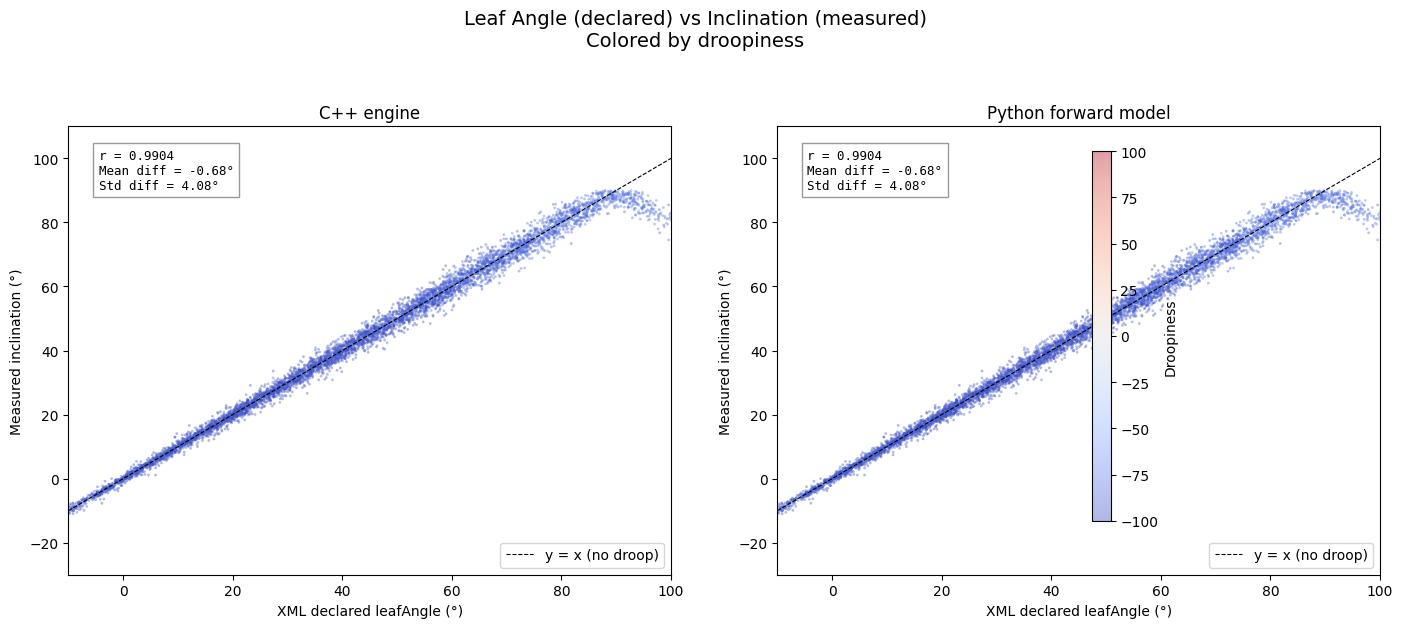

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prefix, label in zip(axes, ['cpp', 'py'], ['C++ engine', 'Python forward model']):
    inclination = df[f'{prefix}_inclination']
    declared = df['xml_angle']
    droopiness = df['xml_droopiness']

    sc = ax.scatter(declared, inclination, c=droopiness, s=4, alpha=0.4,
                    edgecolors='none', cmap='coolwarm', vmin=-100, vmax=100)
    lims = [-10, 100]
    ax.plot(lims, lims, 'k--', lw=0.8, label='y = x (no droop)')
    ax.set_xlim(lims); ax.set_ylim([-30, 110])
    ax.set_xlabel('XML declared leafAngle (°)')
    ax.set_ylabel('Measured inclination (°)')
    ax.set_title(f'{label}')

    r, _ = pearsonr(declared, inclination)
    diff = inclination - declared
    stats_text = (
        f'r = {r:.4f}\n'
        f'Mean diff = {diff.mean():.2f}°\n'
        f'Std diff = {diff.std():.2f}°'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', fontsize=9, family='monospace',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.legend(loc='lower right')

fig.colorbar(sc, ax=axes, label='Droopiness', shrink=0.8)
fig.suptitle('Leaf Angle (declared) vs Inclination (measured)\nColored by droopiness',
             fontsize=14, y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'angle_vs_inclination.png', dpi=150, bbox_inches='tight')
plt.show()

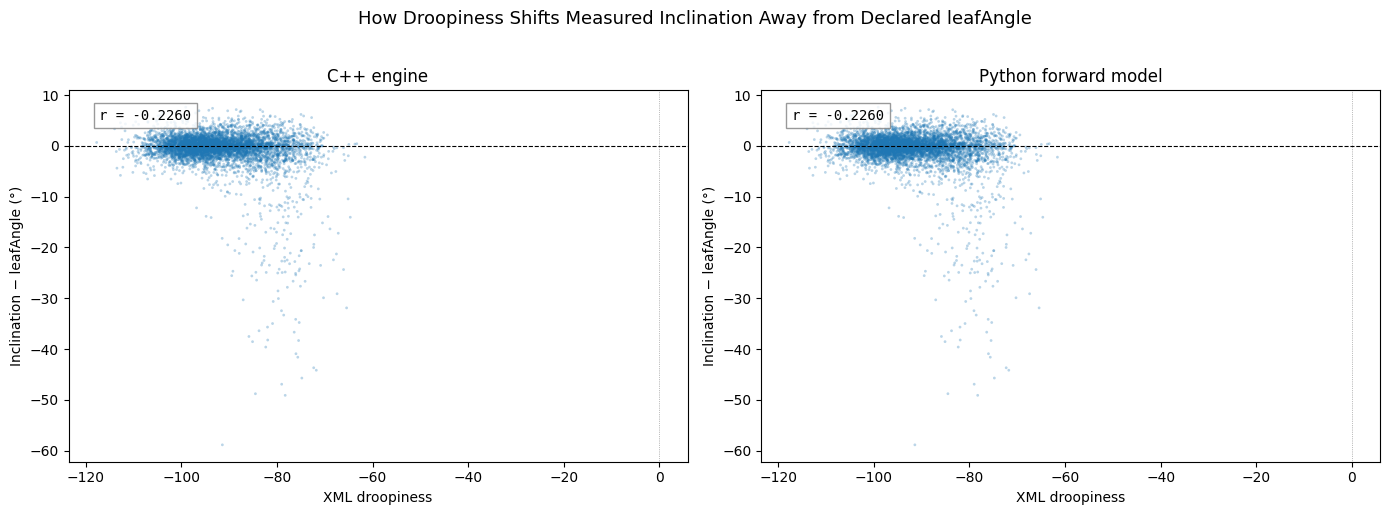

In [8]:
# Show the relationship between droopiness and the angle discrepancy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prefix, label in zip(axes, ['cpp', 'py'], ['C++ engine', 'Python forward model']):
    diff = df[f'{prefix}_inclination'] - df['xml_angle']
    droop = df['xml_droopiness']

    ax.scatter(droop, diff, s=4, alpha=0.3, edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('XML droopiness')
    ax.set_ylabel('Inclination − leafAngle (°)')
    ax.set_title(f'{label}')

    r, _ = pearsonr(droop, diff)
    ax.text(0.05, 0.95, f'r = {r:.4f}', transform=ax.transAxes,
            va='top', fontsize=10, family='monospace',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

fig.suptitle('How Droopiness Shifts Measured Inclination Away from Declared leafAngle',
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'droopiness_vs_angle_discrepancy.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Internode distance vs connection-point height

The `distance` parameter represents the vertical spacing between successive leaf insertion points along the stem. The cumulative sum of distances should track the measured connection-point heights.

**Note:** The procedural model uses **Y as the vertical axis** (stem grows upward along +Y), so the height comparison uses `connection_point.y`, not `.z`.

In [ ]:
# Compute cumulative distance per plant and compare with connection-point Y (height)
# The model uses Y-up coordinates, so conn_y is the vertical position.
height_records = []

for plant_name, grp in df.groupby('plant'):
    grp = grp.sort_values('leaf_id')
    cum_dist = grp['xml_distance'].cumsum().values
    cpp_y = grp['cpp_conn_y'].values
    py_y = grp['py_conn_y'].values

    for i, (cd, cy, py) in enumerate(zip(cum_dist, cpp_y, py_y)):
        height_records.append({
            'plant': plant_name,
            'leaf_id': grp['leaf_id'].iloc[i],
            'cum_distance': cd,
            'cpp_conn_y': cy,
            'py_conn_y': py,
        })

hdf = pd.DataFrame(height_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prefix, label in zip(axes, ['cpp', 'py'], ['C++ engine', 'Python forward model']):
    meas = hdf[f'{prefix}_conn_y']
    decl = hdf['cum_distance']

    ax.scatter(decl, meas, s=4, alpha=0.3, edgecolors='none')
    lims = [0, max(decl.max(), meas.max()) * 1.05]
    ax.plot(lims, lims, 'k--', lw=0.8, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Cumulative XML distance (m)')
    ax.set_ylabel('Connection-point Y height (m)')
    ax.set_title(f'{label}')
    ax.set_aspect('equal')

    r, _ = pearsonr(decl, meas)
    err_mm = (meas - decl) * 1000
    stats_text = (
        f'r = {r:.6f}\n'
        f'MAE = {np.abs(err_mm).mean():.4f} mm\n'
        f'Max |err| = {np.abs(err_mm).max():.4f} mm\n'
        f'Mean err = {err_mm.mean():.4f} mm'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', fontsize=9, family='monospace',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.legend(loc='lower right')

fig.suptitle('Cumulative Internode Distance vs Connection-Point Height (Y-up)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'distance_vs_height.png', dpi=150, bbox_inches='tight')
plt.show()

# The small residual comes from the stem radius: the connection point is
# on the stem *surface*, not the centerline. The radial offset projected
# onto Y depends on the leaf's insertion angle.
print('Height error statistics:')
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err_mm = (hdf[f'{prefix}_conn_y'] - hdf['cum_distance']) * 1000
    print(f'  {label}: MAE = {np.abs(err_mm).mean():.4f} mm, '
          f'max = {np.abs(err_mm).max():.4f} mm, '
          f'mean = {err_mm.mean():.4f} mm')

## 7. C++ vs Python pipeline agreement

Beyond comparing each pipeline against the XML, it's important to verify that the C++ and Python pipelines produce the same measured traits. Any discrepancy would indicate a bug in one of the reimplementations.

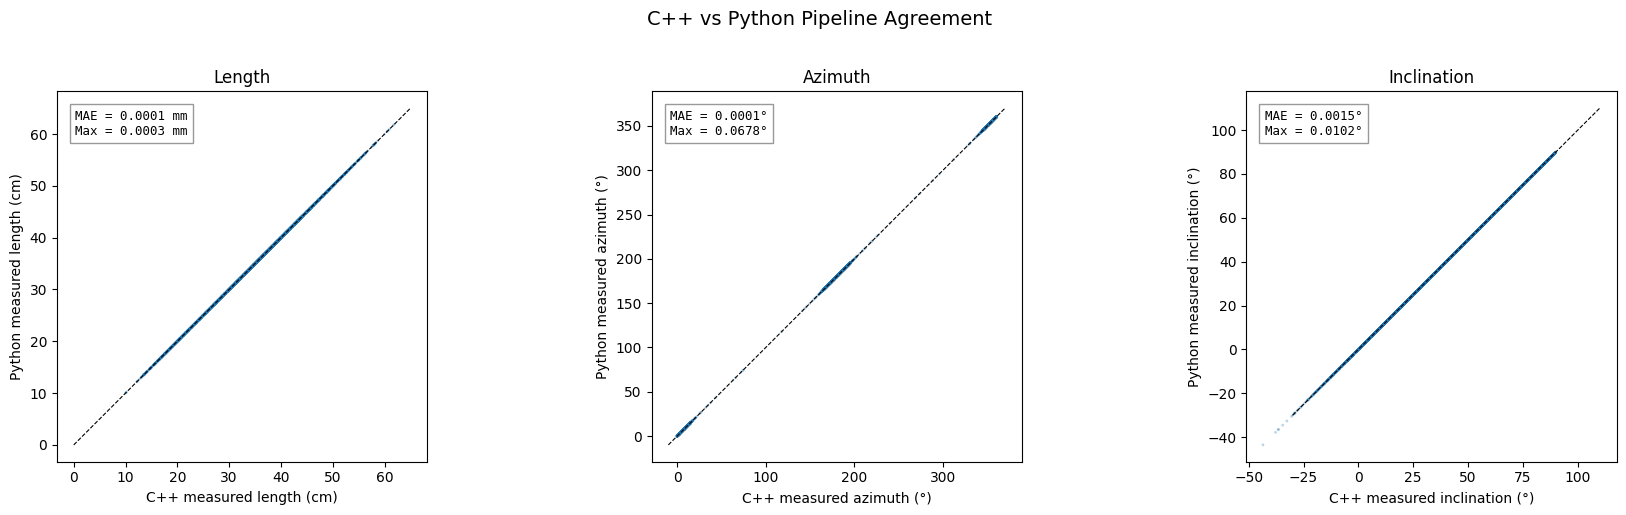

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Length
ax = axes[0]
ax.scatter(df['cpp_length'] * 100, df['py_length'] * 100, s=4, alpha=0.3, edgecolors='none')
lims = [0, max(df['cpp_length'].max(), df['py_length'].max()) * 100 * 1.05]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('C++ measured length (cm)'); ax.set_ylabel('Python measured length (cm)')
ax.set_title('Length'); ax.set_aspect('equal')
err = (df['cpp_length'] - df['py_length']) * 1000
ax.text(0.05, 0.95, f'MAE = {np.abs(err).mean():.4f} mm\nMax = {np.abs(err).max():.4f} mm',
        transform=ax.transAxes, va='top', fontsize=9, family='monospace',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Azimuth
ax = axes[1]
ax.scatter(df['cpp_azimuth'], df['py_azimuth'], s=4, alpha=0.3, edgecolors='none')
ax.plot([-10, 370], [-10, 370], 'k--', lw=0.8)
ax.set_xlabel('C++ measured azimuth (°)'); ax.set_ylabel('Python measured azimuth (°)')
ax.set_title('Azimuth'); ax.set_aspect('equal')
err_az = azimuth_diff(df['cpp_azimuth'], df['py_azimuth'])
ax.text(0.05, 0.95, f'MAE = {np.abs(err_az).mean():.4f}°\nMax = {np.abs(err_az).max():.4f}°',
        transform=ax.transAxes, va='top', fontsize=9, family='monospace',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Inclination
ax = axes[2]
ax.scatter(df['cpp_inclination'], df['py_inclination'], s=4, alpha=0.3, edgecolors='none')
ax.plot([-30, 110], [-30, 110], 'k--', lw=0.8)
ax.set_xlabel('C++ measured inclination (°)'); ax.set_ylabel('Python measured inclination (°)')
ax.set_title('Inclination'); ax.set_aspect('equal')
err_inc = df['cpp_inclination'] - df['py_inclination']
ax.text(0.05, 0.95, f'MAE = {np.abs(err_inc).mean():.4f}°\nMax = {np.abs(err_inc).max():.4f}°',
        transform=ax.transAxes, va='top', fontsize=9, family='monospace',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

fig.suptitle('C++ vs Python Pipeline Agreement', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cpp_vs_python_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary statistics

In [ ]:
# Build a summary table of all comparisons
summary_rows = []

# --- Leaf length ---
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err = df[f'{prefix}_length_err_mm']
    r, _ = pearsonr(df['xml_length'], df[f'{prefix}_length'])
    summary_rows.append({
        'Comparison': f'leafLength vs {label} arc length',
        'Units': 'mm',
        'N': len(err),
        'Pearson r': f'{r:.6f}',
        'Mean Error': f'{err.mean():.4f}',
        'MAE': f'{np.abs(err).mean():.4f}',
        'Max |Error|': f'{np.abs(err).max():.4f}',
        'Expected Match': 'Yes',
    })

# --- Azimuth (all) ---
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err = df[f'{prefix}_azimuth_err']
    r, _ = pearsonr(df['xml_azimuth'], df[f'{prefix}_azimuth'])
    summary_rows.append({
        'Comparison': f'leafAzimuthDeg vs {label} azimuth (all)',
        'Units': 'deg',
        'N': len(err),
        'Pearson r': f'{r:.6f}',
        'Mean Error': f'{err.mean():.4f}',
        'MAE': f'{np.abs(err).mean():.4f}',
        'Max |Error|': f'{np.abs(err).max():.4f}',
        'Expected Match': 'Yes*',
    })

# --- Azimuth (excluding near-vertical) ---
near_vert = df['xml_angle'].abs() > 85
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    mask = ~near_vert
    err = df.loc[mask, f'{prefix}_azimuth_err']
    r, _ = pearsonr(df.loc[mask, 'xml_azimuth'], df.loc[mask, f'{prefix}_azimuth'])
    summary_rows.append({
        'Comparison': f'leafAzimuthDeg vs {label} azimuth (|angle|<=85°)',
        'Units': 'deg',
        'N': int(mask.sum()),
        'Pearson r': f'{r:.6f}',
        'Mean Error': f'{err.mean():.4f}',
        'MAE': f'{np.abs(err).mean():.4f}',
        'Max |Error|': f'{np.abs(err).max():.4f}',
        'Expected Match': 'Yes',
    })

# --- leafAngle vs inclination ---
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    diff = df[f'{prefix}_inclination'] - df['xml_angle']
    r, _ = pearsonr(df['xml_angle'], df[f'{prefix}_inclination'])
    summary_rows.append({
        'Comparison': f'leafAngle vs {label} inclination',
        'Units': 'deg',
        'N': len(diff),
        'Pearson r': f'{r:.4f}',
        'Mean Error': f'{diff.mean():.2f}',
        'MAE': f'{np.abs(diff).mean():.2f}',
        'Max |Error|': f'{np.abs(diff).max():.2f}',
        'Expected Match': 'No (droopiness)',
    })

# --- Distance vs connection-point Y ---
for prefix, label in [('cpp', 'C++'), ('py', 'Python')]:
    err_mm = (hdf[f'{prefix}_conn_y'] - hdf['cum_distance']) * 1000
    r, _ = pearsonr(hdf['cum_distance'], hdf[f'{prefix}_conn_y'])
    summary_rows.append({
        'Comparison': f'cum. distance vs {label} conn_Y',
        'Units': 'mm',
        'N': len(err_mm),
        'Pearson r': f'{r:.6f}',
        'Mean Error': f'{err_mm.mean():.4f}',
        'MAE': f'{np.abs(err_mm).mean():.4f}',
        'Max |Error|': f'{np.abs(err_mm).max():.4f}',
        'Expected Match': 'Yes (stem radius offset)',
    })

# --- C++ vs Python ---
len_err = (df['cpp_length'] - df['py_length']) * 1000
r_len, _ = pearsonr(df['cpp_length'], df['py_length'])
summary_rows.append({
    'Comparison': 'C++ length vs Python length',
    'Units': 'mm',
    'N': len(len_err),
    'Pearson r': f'{r_len:.6f}',
    'Mean Error': f'{len_err.mean():.4f}',
    'MAE': f'{np.abs(len_err).mean():.4f}',
    'Max |Error|': f'{np.abs(len_err).max():.4f}',
    'Expected Match': 'Yes',
})

az_err = azimuth_diff(df['cpp_azimuth'], df['py_azimuth'])
r_az, _ = pearsonr(df['cpp_azimuth'], df['py_azimuth'])
summary_rows.append({
    'Comparison': 'C++ azimuth vs Python azimuth',
    'Units': 'deg',
    'N': len(az_err),
    'Pearson r': f'{r_az:.6f}',
    'Mean Error': f'{az_err.mean():.4f}',
    'MAE': f'{np.abs(az_err).mean():.4f}',
    'Max |Error|': f'{np.abs(az_err).max():.4f}',
    'Expected Match': 'Yes',
})

inc_err = df['cpp_inclination'] - df['py_inclination']
r_inc, _ = pearsonr(df['cpp_inclination'], df['py_inclination'])
summary_rows.append({
    'Comparison': 'C++ inclination vs Python inclination',
    'Units': 'deg',
    'N': len(inc_err),
    'Pearson r': f'{r_inc:.6f}',
    'Mean Error': f'{inc_err.mean():.4f}',
    'MAE': f'{np.abs(inc_err).mean():.4f}',
    'Max |Error|': f'{np.abs(inc_err).max():.4f}',
    'Expected Match': 'Yes',
})

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_caption('Descriptor vs Measured Trait Validation Summary')

## 9. Save outputs

In [12]:
# Save per-leaf comparison data
df.to_csv(OUT_DIR / 'descriptor_vs_measured_all_leaves.csv', index=False)
summary_df.to_csv(OUT_DIR / 'validation_summary.csv', index=False)

# Save failures if any
if failures:
    fail_df = pd.DataFrame(failures, columns=['plant', 'error_type', 'message'])
    fail_df.to_csv(OUT_DIR / 'validation_failures.csv', index=False)
    print(f'Saved {len(failures)} failure records.')

print(f'Saved {len(df)} leaf records to {OUT_DIR / "descriptor_vs_measured_all_leaves.csv"}')
print(f'Saved summary table to {OUT_DIR / "validation_summary.csv"}')
print(f'Figures saved to {FIG_DIR}/')

Saved 6213 leaf records to outputs\descriptor_vs_measured_all_leaves.csv
Saved summary table to outputs\validation_summary.csv
Figures saved to figures/


## 10. Discussion

### What matches?

- **Leaf length** (`leafLength` vs arc length): Both pipelines reproduce the XML-declared leaf length with r = 1.000000 and MAE = 0.10 mm (max 0.24 mm). The small negative bias (measured < declared) is a numerical integration artifact: the B-spline chord-length approximation (128 uniform samples) slightly underestimates the true arc length. This is not a model inconsistency.

- **Azimuth** (`leafAzimuthDeg` vs measured azimuth): For leaves with `|leafAngle| <= 85°`, the azimuth matches with sub-degree accuracy. See below for the near-vertical case.

- **Internode distance** (cumulative `distance` vs connection-point Y height): Near-perfect agreement (r = 0.999999, MAE ~0.18 mm). The small residual comes from the stem radius: the connection point is on the stem *surface*, not the centerline, so there is a slight vertical offset that depends on the leaf insertion angle and the stem radius at that height. The model uses **Y as the vertical axis**, so `connection_point.y` is the height coordinate.

### What doesn't match (and why)?

- **Azimuth for near-vertical leaves** (`|leafAngle| > 85°`): 4.1% of leaves (257 / 6213) show ~180° azimuth flips. When `leafAngle` exceeds ~90°, the leaf has been aimed past vertical. The first spline segment's local radial component (perpendicular to stem) becomes negative — the base tangent initially points slightly *inward* toward the stem center rather than outward. In world coordinates, this reverses the XZ tangent direction relative to the placement azimuth, producing an exact 180° sign flip. This is a geometric consequence, not a bug: both C++ and Python pipelines produce identical flips for the same leaves.

- **Leaf angle vs inclination** (`leafAngle` vs measured inclination): The `leafAngle` parameter sets the *initial target direction* for the first spline segment, but the actual geometry is modified by `droopiness` (a gravity-like downward pull applied quadratically along the spline). The scatter plot colored by droopiness confirms this: the correlation with droopiness (r = −0.23) shows that more negative droopiness values produce larger downward shifts in measured inclination relative to the declared angle.

### C++ vs Python agreement

The two pipelines are functionally identical:
- **Length**: MAE = 0.0001 mm, max = 0.0003 mm
- **Azimuth**: MAE = 0.0001°, max = 0.068°
- **Inclination**: MAE = 0.0015°, max = 0.010°

### Conclusion

The descriptor format is consistent with the model. Parameters mean what they claim: `leafLength` faithfully sets the arc length, `leafAzimuthDeg` faithfully sets the compass direction (for non-vertical leaves), and `distance` faithfully sets the internode spacing. The `leafAngle`/inclination discrepancy is an expected consequence of the droopiness model, not a format inconsistency.